## DS 4420 - Proof of Concept (Data Pre-processing)

- Key Question: to what extent can a game's content, quality, and engagement metrics be used to predict its price on the Steam marketplace?" 

- File purpose: Pre-processing the data to save as a new CSV

- Date: 03/13

- Authors: Gianna Saw, Jason Zheng 


## Understanding our data

In [1]:
# importing data 
import pandas as pd 
import numpy as np

In [2]:
# loading the df 
import pandas as pd

raw = pd.read_csv(
    "games.csv",
    quotechar='"',
    escapechar='\\',
    engine="python",
    on_bad_lines="skip"
)

raw.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [3]:
# double checking we are reading the csv correctly 
# raw.columns
raw.iloc[5]

AppID                                                                  Agony VR
Name                                                                Apr 5, 2023
Release date                                                          0 - 20000
Estimated owners                                                              0
Peak CCU                                                                      0
Required age                                                              13.99
Price                                                                         0
DiscountDLC count                                                             0
About the game                A JOURNEY THROUGH HELL! Explore the most terri...
Supported languages           ['English', 'French', 'Italian', 'German', 'Sp...
Full audio languages                                     ['English', 'Turkish']
Reviews                                                                     NaN
Header image                  https://sh

In [4]:
# understanding the column names to work with a smaller df 
raw.columns

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='object')

#### Columns that we want to keep to match our RQ

- Target variable: 'price'
- Engagement metrics:
    - Peak CCU
    - Positive
    - Negative
    - Recommendations
    - Average playtime forever
    - Average playtime two weeks
    - Median playtime forever
    - Median playtime two weeks
    - Supported languages

- Quality metrics: 
    - Metacritic score
    - User score
    - Score rank

- Content features: 
    - Achievements
    - DiscountDLC count
    - Required age

- Platform support: 
    - Windows
    - Mac
    - Linux


In [5]:
# dropping unecessary columns to work with smaller data
drop_cols = [
    "AppID",
    "Name",
    "Release date",
    "About the game",
    "Full audio languages",
    "Developers", 
    "Publishers",
    "Reviews",
    "Header image",
    "Website",
    "Support url",
    "Support email",
    "Metacritic url",
    "Notes",
    "Screenshots",
    "Movies",
    "Tags"
]

steam = raw.drop(columns=drop_cols)

In [6]:
# printing our new data
steam.head(5)

,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,Supported languages,Windows,Mac,Linux,Metacritic score,...,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Categories,Genres
2539430,0,0,0.00,0,0,[],True,False,False,0,...,0,NaN,0,0,0,0,0,0,NaN,NaN
496350,0,0,5.24,65,0,['English'],True,False,False,0,...,3,NaN,0,231,8,0,8,0,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure
1034400,0,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",True,True,False,0,...,3,NaN,0,0,0,0,0,0,"Single-player,Family Sharing",Casual
3292190,1,0,8.99,0,1,['Korean'],True,False,False,0,...,0,NaN,19,0,0,0,0,0,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation"
3631080,0,0,4.99,0,0,['English'],True,False,False,0,...,0,NaN,0,0,0,0,0,0,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access"


### Converting lists into numeric features

In [7]:
# checking cols type 
steam.dtypes

Estimated owners                int64
Peak CCU                        int64
Required age                  float64
Price                           int64
DiscountDLC count               int64
Supported languages            object
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
User score                      int64
Positive                        int64
Negative                        int64
Score rank                    float64
Achievements                    int64
Recommendations                 int64
Average playtime forever        int64
Average playtime two weeks      int64
Median playtime forever         int64
Median playtime two weeks       int64
Categories                     object
Genres                         object
dtype: object

##### Cols that need some extra encoding -- Catgories, supported languages, genres, Window/Linux/Mac
- Future steps: working with one-hot encoding for encoded genre/category columns to improve our model
- but for now, we will be working with counting supported languages --> turning to numeric 
- Window / Linux / Mac columns are booleans --> change to numeric (0/1)
- but genres and categories will need some extra one-hot encoding later on, but for now we will create a seperate df

Supported languages 

In [8]:
# Converting supported languages into numeric features, using lambda func
steam['language_count'] = steam['Supported languages'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

In [9]:
# dropping the OG col
steam = steam.drop(columns=['Supported languages'])

In [10]:
# running to see if it actually works 
steam['language_count'].head(3)

2539430    0
496350     0
1034400    0
Name: language_count, dtype: int64

Converting Window Mac Linux from boolean into numeric

In [11]:
steam[['Windows', 'Mac', 'Linux']] = steam[['Windows', 'Mac', 'Linux']].astype(int)

Categories & Genres

In [12]:
# keep numeric-only df for POC
steam_numeric = steam.drop(columns=['Categories', 'Genres'])

# separate df with encoded categoricals for Phase II
steam_encoded = steam.copy()

# encode genres
genre_dummies = steam_encoded['Genres'].str.get_dummies(sep=',')

# encode categories
cat_dummies = steam_encoded['Categories'].str.get_dummies(sep=',')

# concat everything
steam_encoded = pd.concat([steam_encoded, genre_dummies, cat_dummies], axis=1)
steam_encoded = steam_encoded.drop(columns=['Categories', 'Genres'])

In [13]:
steam_encoded

,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,Windows,Mac,Linux,Metacritic score,User score,...,SteamVR Collectibles,Stereo Sound,Subtitle Options,Surround Sound,Touch Only Option,Tracked Controller Support,VR Only,VR Support,VR Supported,Valve Anti-Cheat enabled
2539430,0,0,0.00,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496350,0,0,5.24,65,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1034400,0,0,4.99,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3292190,1,0,8.99,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3631080,0,0,4.99,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152910,0,0,0.00,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4042800,0,0,0.00,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3522550,0,0,7.99,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3680350,0,0,2.09,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


##### Handling NaNs and skewed engagement data

In [14]:
# checking for NaNs
steam.isnull().sum().sort_values(ascending=False)

Score rank                    122566
Categories                      8953
Genres                          8413
Estimated owners                   0
Peak CCU                           0
Median playtime two weeks          0
Median playtime forever            0
Average playtime two weeks         0
Average playtime forever           0
Recommendations                    0
Achievements                       0
Negative                           0
Positive                           0
User score                         0
Metacritic score                   0
Linux                              0
Mac                                0
Windows                            0
DiscountDLC count                  0
Price                              0
Required age                       0
language_count                     0
dtype: int64

In [15]:
# info above tells us rank isn't as useful
steam = steam.drop(columns=["Score rank"])
steam = steam.drop(columns=["Categories", "Genres"])

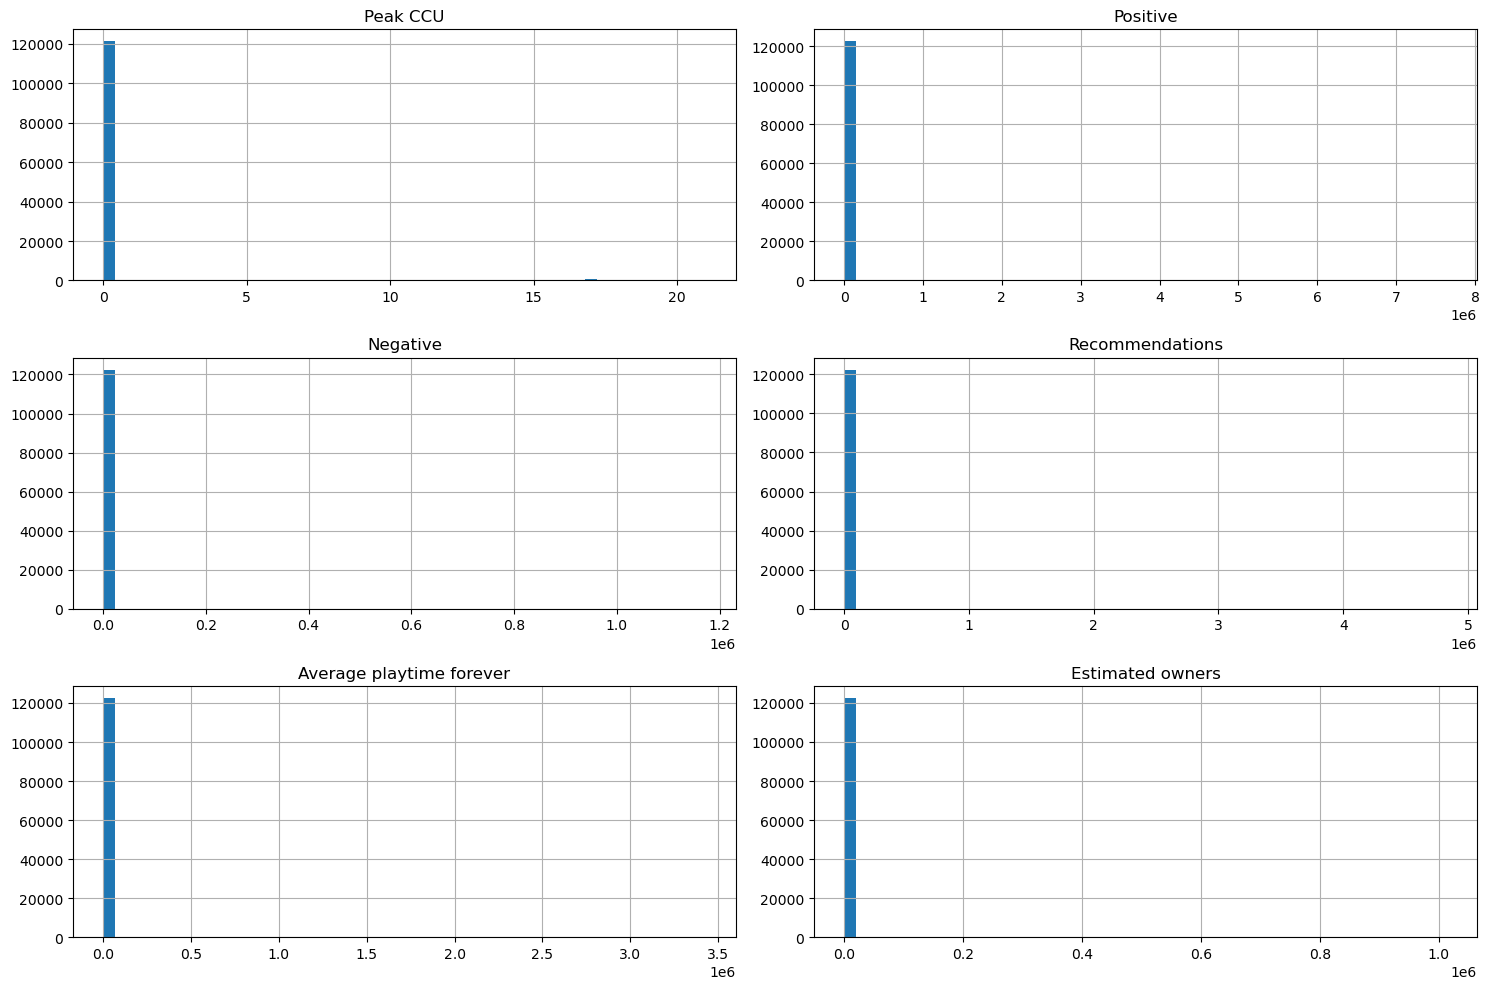

In [16]:
# checking for skewness 

import matplotlib.pyplot as plt

skewed_cols = ['Peak CCU', 'Positive', 'Negative', 
               'Recommendations', 'Average playtime forever',
               'Estimated owners']

steam_numeric[skewed_cols].hist(bins=50, figsize=(15,10))
plt.tight_layout()
plt.show()

- As we see from graph above, our engagement variables are extremely skewed. 
- Almost all games have very low values. A few games have extremely large values 
- Proceeding to training NN models with this data can hurt our models, so we need to fix the skeweness using log transformation

In [17]:
log_cols = ['Peak CCU', 'Positive', 'Negative', 'Recommendations', 
            'Average playtime forever', 'Average playtime two weeks',
            'Median playtime forever', 'Median playtime two weeks',
            'Estimated owners']

for col in log_cols:
    steam[col] = np.log1p(steam[col])

# also transform target variable
steam['Price'] = np.log1p(steam['Price'])

In [18]:
steam

,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,language_count
2539430,0.000000,0.0,0.00,0.000000,0,1,0,0,0,0,0.000000,0.000000,0,0.000000,0.000000,0.0,0.000000,0.0,0
496350,0.000000,0.0,5.24,4.189655,0,1,0,0,0,0,5.533389,1.386294,0,5.446737,2.197225,0.0,2.197225,0.0,0
1034400,0.000000,0.0,4.99,0.000000,0,1,1,0,0,0,3.091042,1.386294,0,0.000000,0.000000,0.0,0.000000,0.0,0
3292190,0.693147,0.0,8.99,0.000000,1,1,0,0,0,0,0.000000,0.000000,19,0.000000,0.000000,0.0,0.000000,0.0,0
3631080,0.000000,0.0,4.99,0.000000,0,1,0,0,0,0,0.000000,0.000000,0,0.000000,0.000000,0.0,0.000000,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152910,0.000000,0.0,0.00,0.000000,0,1,0,0,0,0,0.000000,0.000000,0,0.000000,0.000000,0.0,0.000000,0.0,0
4042800,0.000000,0.0,0.00,0.000000,0,1,0,0,0,0,0.000000,0.000000,0,0.000000,0.000000,0.0,0.000000,0.0,0
3522550,0.000000,0.0,7.99,0.000000,0,1,0,0,0,0,0.000000,0.000000,0,0.000000,0.000000,0.0,0.000000,0.0,0
3680350,0.000000,0.0,2.09,0.000000,0,1,0,0,0,0,0.000000,0.000000,0,0.000000,0.000000,0.0,0.000000,0.0,0


### Filter to paid games only 

- Free-to-play games behave completely differently from paid games and will distort our models, so we will be dropping free games

In [19]:
# dropping free games then printing out the shape
steam = steam[steam['Price'] > 0]
print(steam.shape)

(40677, 19)


In [20]:
steam.head(5)

,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,language_count
496350,0.000000,0.0,5.24,4.189655,0,1,0,0,0,0,5.533389,1.386294,0,5.446737,2.197225,0.000000,2.197225,0.000000,0
1934300,2.197225,0.0,35.99,2.397895,1,1,0,0,0,0,4.770685,2.639057,0,4.682131,6.516193,0.000000,7.134094,0.000000,0
2113450,0.000000,0.0,1.49,4.262680,0,1,1,0,0,0,4.174387,1.098612,13,0.000000,0.000000,0.000000,0.000000,0.000000,0
2922740,0.000000,0.0,1.35,4.204693,0,1,0,0,0,0,3.555348,2.397895,5,0.000000,0.000000,0.000000,0.000000,0.000000,0
688420,4.174387,0.0,2.99,4.394449,1,1,1,0,0,0,9.338558,6.723832,11,9.328212,5.837730,4.465908,5.159055,4.941642,0


Quick notes: 
- Our final dataset after pre-processing has now 40k rows, filtering out free games:

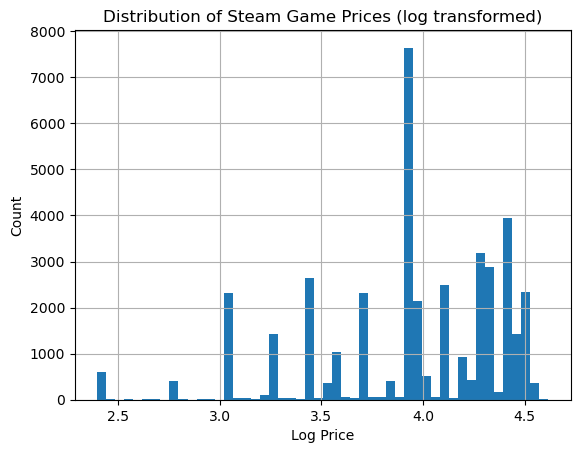

In [21]:
## Printing out price ranges
steam['Price'].hist(bins=50)
plt.xlabel('Log Price')
plt.ylabel('Count')
plt.title('Distribution of Steam Game Prices (log transformed)')
plt.show()

In [22]:
# saving the cleaned df as a csv
steam.to_csv("steam_clean.csv", index=False)